In [4]:
import pandas as pd
import numpy as np
import  matplotlib.pyplot as plt
from sklearn.datasets import load_wine

%matplotlib inline  

In [5]:
plt.rcParams['figure.figsize'] = (12,9)

Read the data 

In [6]:
wine_data = load_wine()

wine_df = pd.DataFrame(
   data = wine_data.data,
   columns = wine_data.feature_names
)

wine_df['target'] = wine_data.target
wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


/Users/oluwatosin/anaconda3/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 8.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


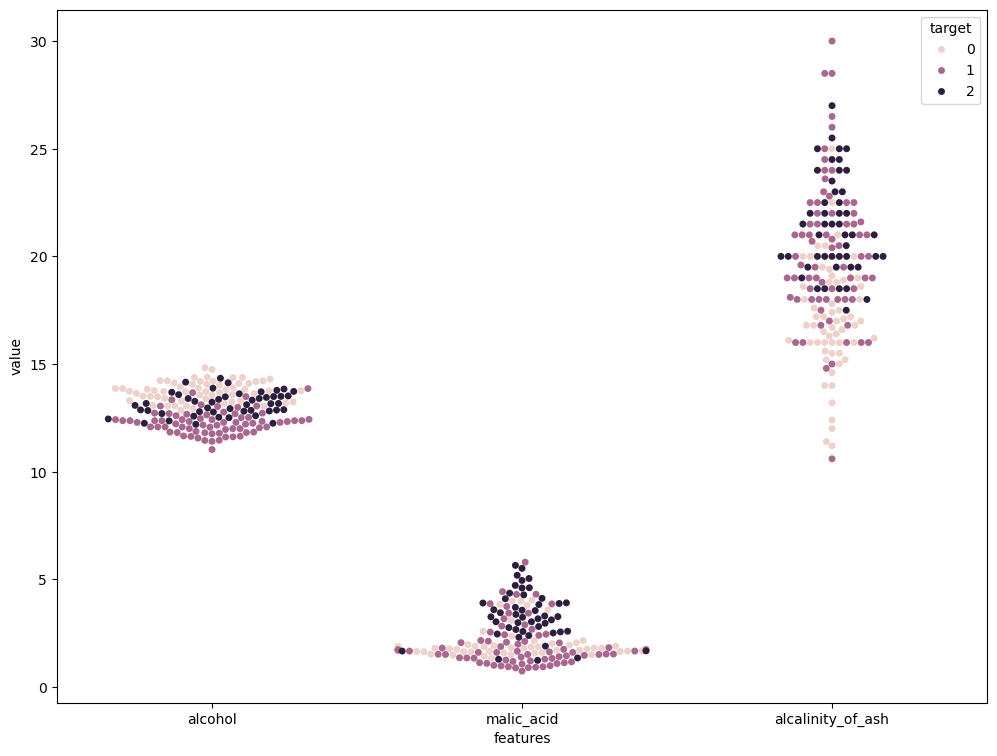

In [7]:
from seaborn import swarmplot
data_to_plot = pd.melt(wine_df[['alcohol','malic_acid', 'alcalinity_of_ash', 'target']],
                       id_vars= 'target',
                       var_name='features',
                       value_name='value')
swarmplot(data=data_to_plot, x = 'features', y = 'value', hue='target')
plt.show()


In [8]:
wine_df['target'].value_counts()

target
1    71
0    59
2    48
Name: count, dtype: int64

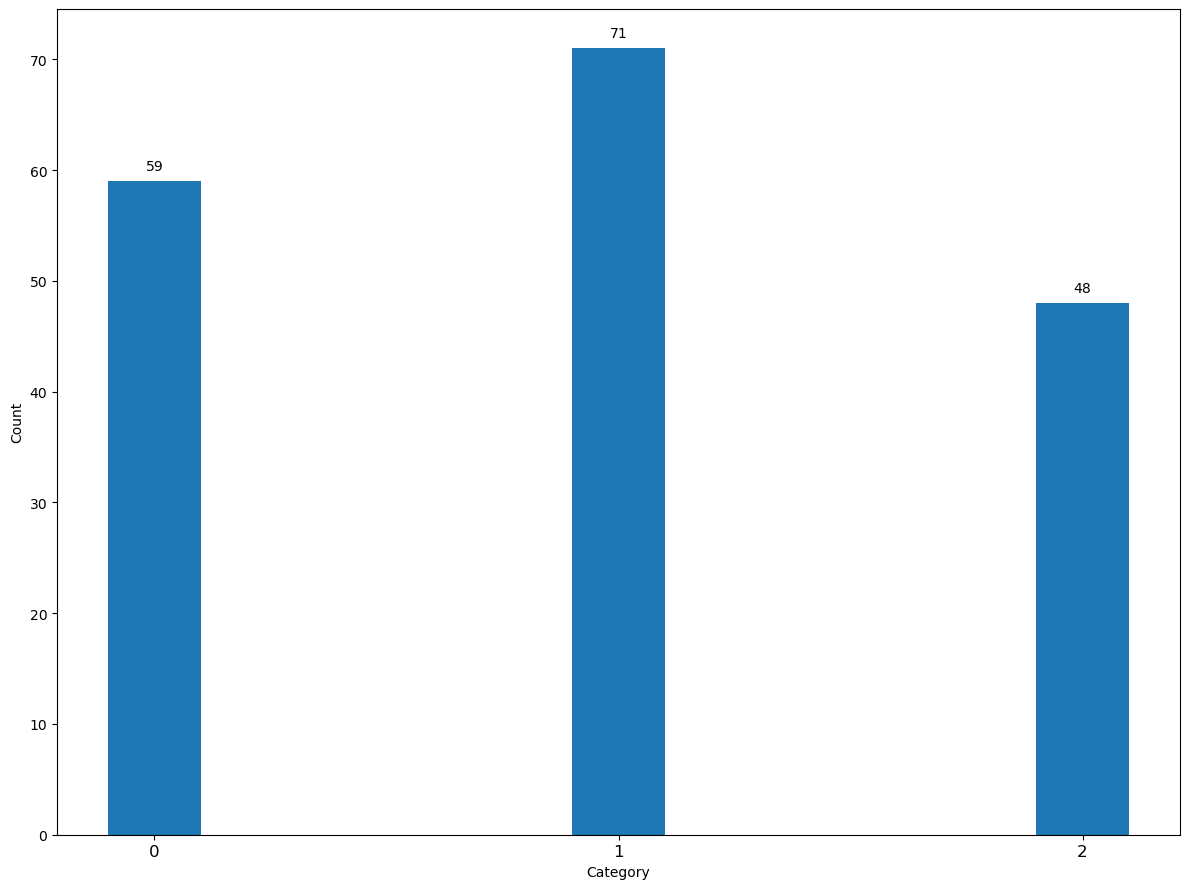

In [9]:
fig, ax = plt.subplots()
x = [0,1,2]
y =[59,71,48]

ax.bar(x,y, width = 0.2)
ax.set_xlabel('Category')
ax.set_ylabel('Count')
ax.set_xticks([0,1,2])
ax.set_xticklabels([0,1,2], fontsize = 12)

for index, value in  enumerate(y):
   plt.text(x=int(index), y=value+1,s=str(value), ha='center')
   
plt.tight_layout()
plt.show()



In [10]:
from sklearn.model_selection import train_test_split
x = wine_df.drop(['target'], axis = 1)
y = wine_df['target']
x_train, x_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size = 0.3,
                                                    shuffle = True,
                                                    stratify = y,
                                                    random_state = 42)

In [11]:
print(x_train.shape)
print(x_test.shape)

(124, 13)
(54, 13)


Baseline Model: Gradient Boosting Classifier with all feature

In [12]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score

# Initialise classifier
gbc = GradientBoostingClassifier(max_depth = 5, random_state = 42)

# Train classifier using all features
gbc.fit(x_train, y_train)

# Make predictions
preds = gbc.predict(x_train)


# Make predictions on the test set to match y_test length
preds = gbc.predict(x_test)

# Evaluate the model using the weighted F1-score
f1_score_all = round(f1_score(y_test, preds, average='weighted'), 3)


print(f1_score_all)

0.908


Feature Selection Techniques

Variance Threshold 

In [13]:
x_train_v1, x_test_v1, y_train_v1, y_test_v1 = x_train.copy(), x_test.copy(), y_train.copy(), y_test.copy()

In [14]:
# Calculate the variance of each feature
x_train_v1.var(axis=0)

alcohol                             0.658341
malic_acid                          1.123507
ash                                 0.072433
alcalinity_of_ash                  11.471279
magnesium                         232.071532
total_phenols                       0.393226
flavanoids                          0.912299
nonflavanoid_phenols                0.013873
proanthocyanins                     0.335108
color_intensity                     5.669722
hue                                 0.052891
od280/od315_of_diluted_wines        0.470021
proline                         94906.710923
dtype: float64

In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_x_train_v1 = scaler.fit_transform(x_train_v1)

scaler = MinMaxScaler()
scaled_x_train_v1 = scaler.fit_transform(x_train_v1)


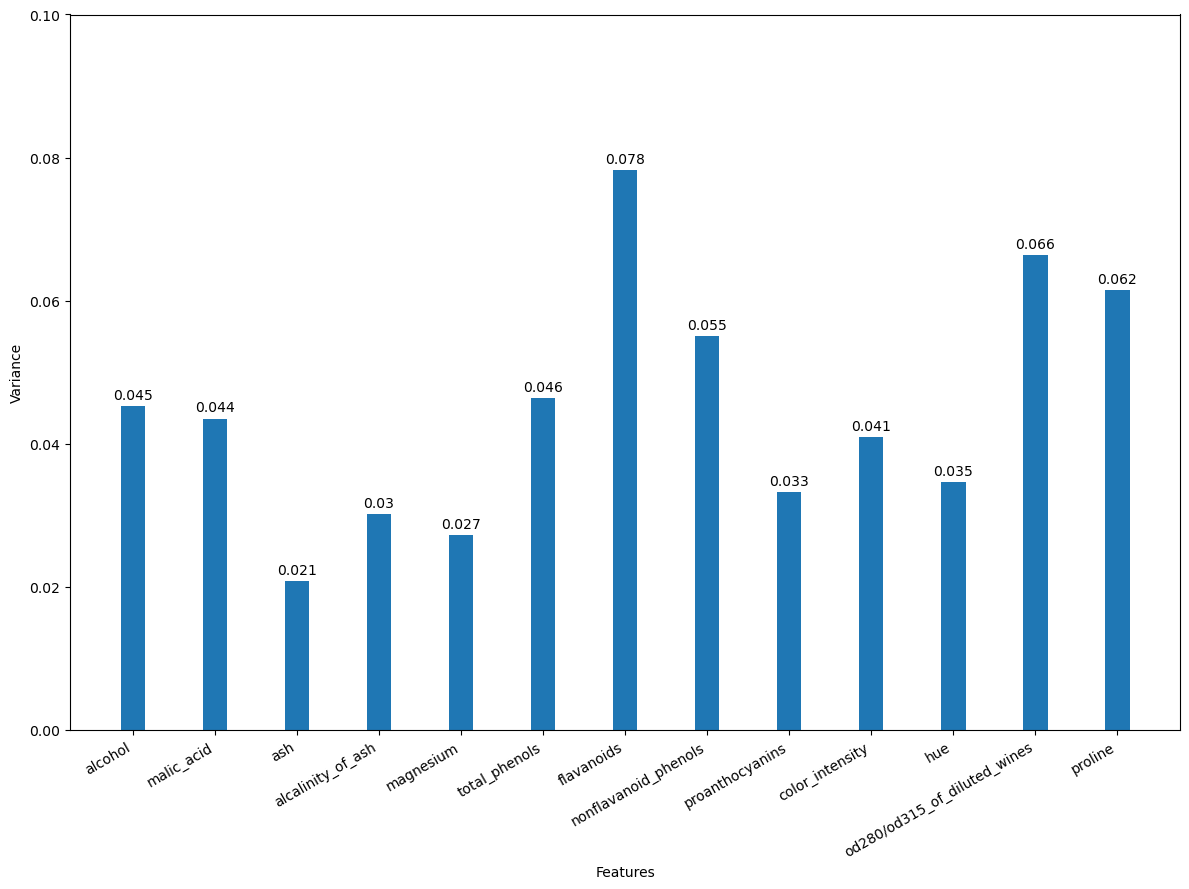

In [55]:
fig, ax = plt.subplots()
x = x_train_v1.columns
y = scaled_x_train_v1.var(axis=0)
ax.bar(x,y, width = 0.3)
ax.set_xlabel('Features')
ax.set_ylabel('Variance')
ax.set_ylim(0, 0.1)

for index, value in  enumerate(y):
   plt.text(x=index, y=value+0.001,s=str(round(value, 3)), ha='center')

fig.autofmt_xdate()
fig.tight_layout()
plt.show()


In [17]:
sel_x_train_v1 = x_train_v1.drop(['ash', 'magnesium'], axis=1)
sel_x_test_v1 = x_test_v1.drop(['ash', 'magnesium'], axis=1)
gbc.fit(x_train_v1, y_train_v1)
gbc.fit(sel_x_train_v1, y_train_v1)
var_preds = gbc.predict(sel_x_test_v1)
f1_score_var = round(f1_score(y_test_v1, var_preds, average='weighted'), 3)
print(f1_score_var)

0.963


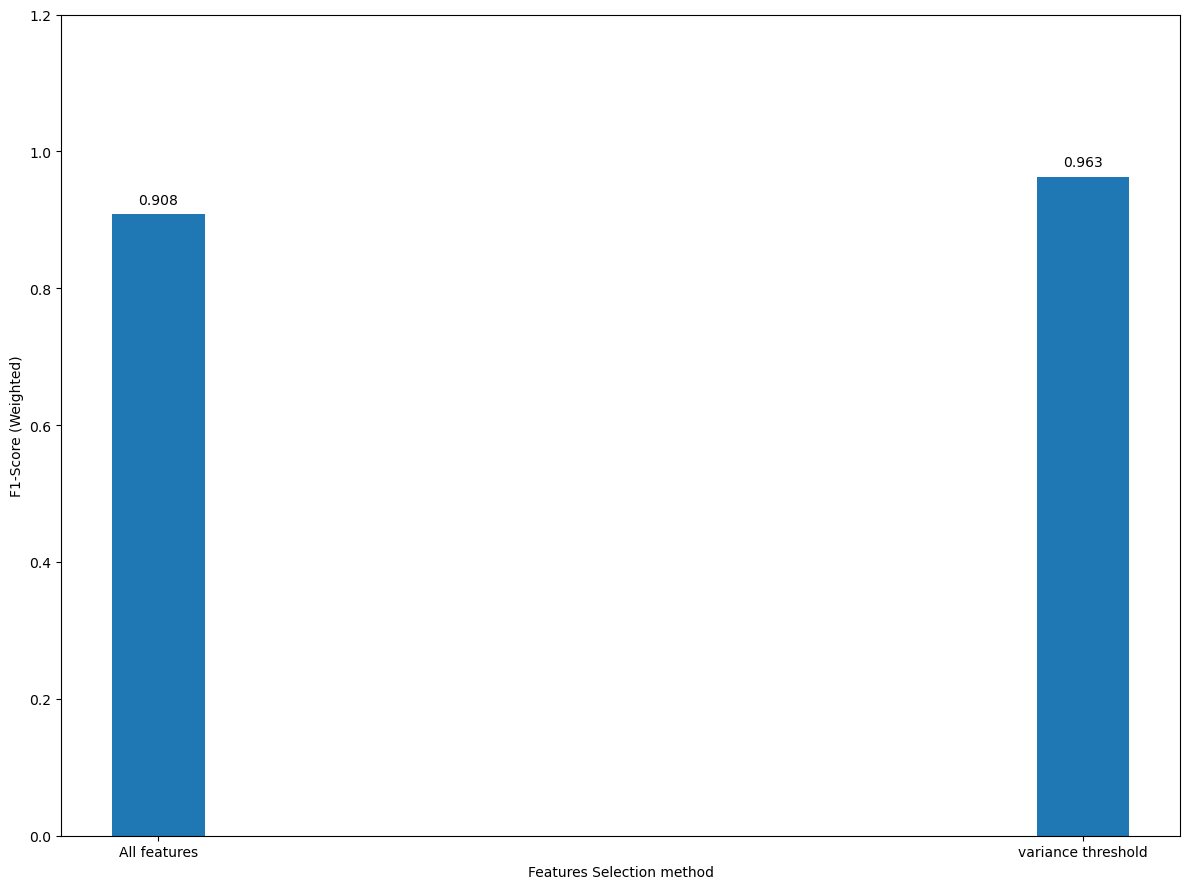

In [54]:
fig, ax = plt.subplots()
x = ['All features', 'variance threshold']
y = [f1_score_all, f1_score_var]
ax.bar(x,y, width = 0.1)
ax.set_xlabel('Features Selection method')
ax.set_ylabel('F1-Score (Weighted)')
ax.set_ylim(0, 1.2)

for index, value in  enumerate(y):
   plt.text(x=index, y=value+0.015,s=str(round(value, 3)), ha='center')

fig.tight_layout()
plt.show()


K-Best Features Method

In [19]:
x_train_v2, x_test_v2, y_train_v2, y_test_v2 = x_train.copy(), x_test.copy(), y_train.copy(), y_test.copy()

In [20]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif


   
f1_score_list = []
for k in range(1, 14):
      selector = SelectKBest(mutual_info_classif, k=k)
      selector.fit(x_train_v2, y_train_v2)

      sel_x_train_v2 = selector.transform(x_train_v2)
      sel_x_test_v2 = selector.transform(x_test_v2)

      gbc.fit(sel_x_train_v2, y_train_v2)
      kbest_preds = gbc.predict(sel_x_test_v2)

      f1_score_kbest = round(
         f1_score(y_test_v2, kbest_preds, average="weighted"),3)
      f1_score_list.append(f1_score_kbest)
   

/var/folders/yf/ctf55y_d13n1lmhjp18rdgvw0000gn/T/ipykernel_5282/906547736.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x)
/var/folders/yf/ctf55y_d13n1lmhjp18rdgvw0000gn/T/ipykernel_5282/906547736.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x, fontsize = 12)


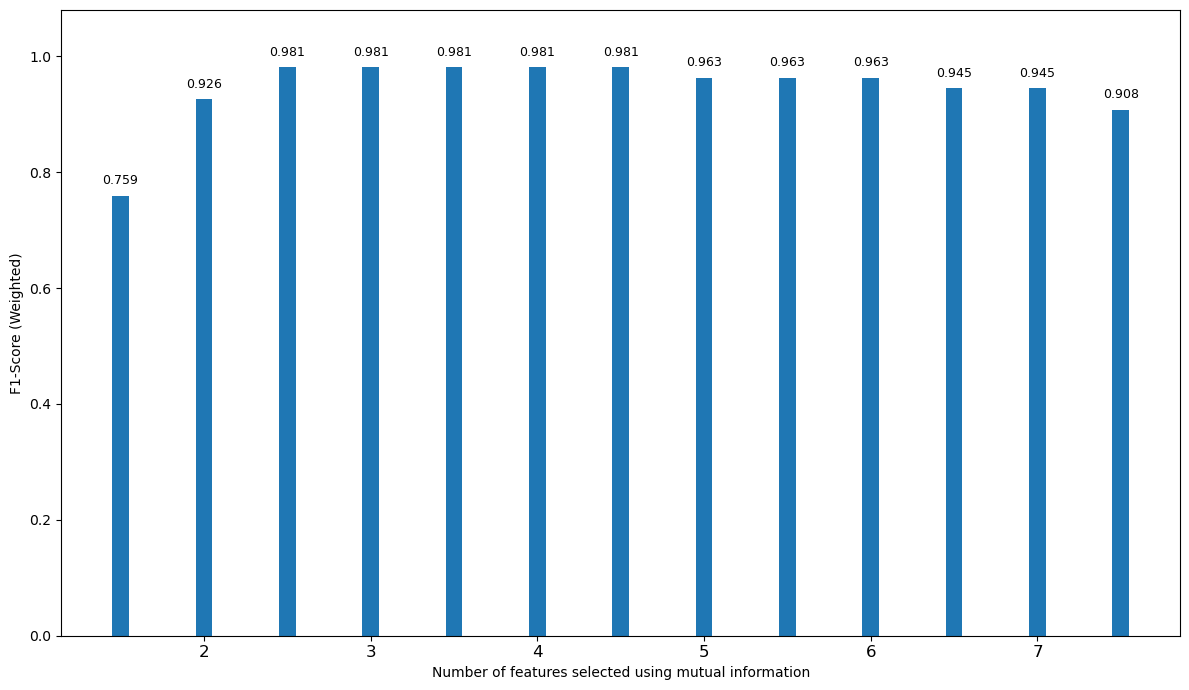

In [21]:
fig, ax = plt.subplots(figsize=(12,7))
x = np.arange(1, 14)
y = f1_score_list
ax.bar(x,y, width = 0.2)
ax.set_xlabel('Number of features selected using mutual information')
ax.set_ylabel('F1-Score (Weighted)')
ax.set_ylim(0, 1.08)
ax.set_xticklabels(x)
ax.set_xticklabels(x, fontsize = 12)

for index, value in enumerate(y, start=1):
    ax.text(
        index,
        value + 0.015,          
        f'{value:.3f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

fig.tight_layout()
plt.show()


In [22]:
selector = selector = SelectKBest(mutual_info_classif, k=3)
selector.fit(x_train_v2, y_train_v2)

selected_feature_mask = selector.get_support()

selected_features = x_train_v2.columns[selected_feature_mask]
selected_features

Index(['flavanoids', 'color_intensity', 'proline'], dtype='object')

Recursive Feature elimination (FRE)

In [23]:
x_train_v3, x_test_v3, y_train_v3, y_test_v3 = x_train.copy(), x_test.copy(), y_train.copy(), y_test.copy()

In [24]:
from sklearn.feature_selection import RFE

rfe_f1_score_list = []
for k in range(1, 14):
      RFE_selector = RFE(estimator=gbc, n_features_to_select=k, step=1)
      RFE_selector.fit(x_train_v3, y_train_v3)

      sel_x_train_v3 = RFE_selector.transform(x_train_v3)
      sel_x_test_v3 = RFE_selector.transform(x_test_v3)

      gbc.fit(sel_x_train_v3, y_train_v3)
      RFE_preds = gbc.predict(sel_x_test_v3)

      f1_score_rfe = round(f1_score(y_test_v3, RFE_preds, average="weighted"),3)
      rfe_f1_score_list.append(f1_score_rfe)

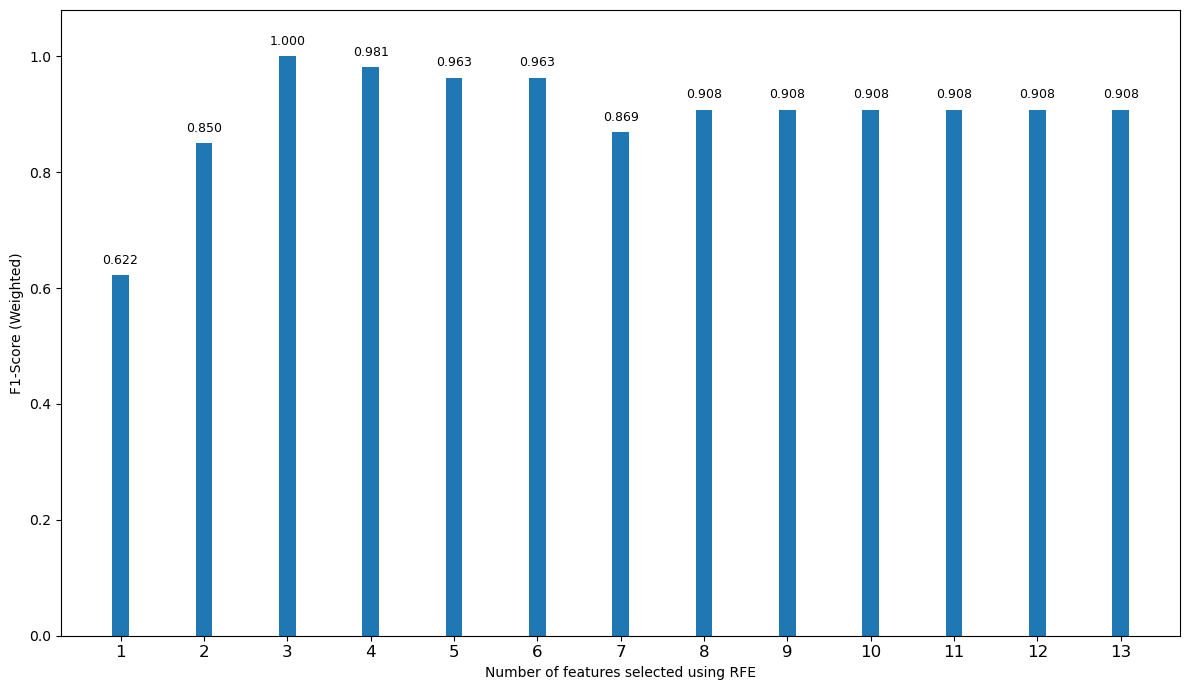

In [25]:
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(1, 14)
y = rfe_f1_score_list

# Create bars
bars = ax.bar(x, y, width=0.2)

# Axis labels
ax.set_xlabel('Number of features selected using RFE')
ax.set_ylabel('F1-Score (Weighted)')


ax.set_ylim(0, 1.08)

# X-axis ticks
ax.set_xticks(x)
ax.set_xticklabels(x, fontsize=12)

# Add values above bars
for index, value in enumerate(y, start=1):
    ax.text(
        index,
        value + 0.015,          
        f'{value:.3f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()


In [26]:
RFE_selector = RFE(estimator=gbc, n_features_to_select=3, step=1)
RFE_selector.fit(x_train_v3, y_train_v3)

selected_feature_mask_rfe = RFE_selector.get_support()

selected_features_rfe = x_train_v3.columns[selected_feature_mask_rfe]
selected_features_rfe

Index(['color_intensity', 'od280/od315_of_diluted_wines', 'proline'], dtype='object')

Boruta

In [27]:
x_train_v4, x_test_v4, y_train_v4, y_test_v4 = x_train.copy(), x_test.copy(), y_train.copy(), y_test.copy()

In [28]:
from boruta import BorutaPy

boruta_selector = BorutaPy(gbc, random_state=42)
boruta_selector.fit(x_train_v4.values, y_train_v4.values.ravel())

sel_x_train_v4 = boruta_selector.transform(x_train_v4.values)
sel_x_test_v4 = boruta_selector.transform(x_test_v4.values)

gbc.fit(sel_x_train_v4, y_train_v4)
boruta_preds = gbc.predict(sel_x_test_v4)
f1_score_boruta = round(f1_score(y_test_v4, boruta_preds, average="weighted"), 3)
print(f1_score_boruta)

0.982


In [30]:
selected_features_mask = boruta_selector.support_

selected_features = x_train_v4.columns[selected_features_mask]
selected_features 

Index(['malic_acid', 'ash', 'magnesium', 'flavanoids', 'proanthocyanins',
       'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline'],
      dtype='object')

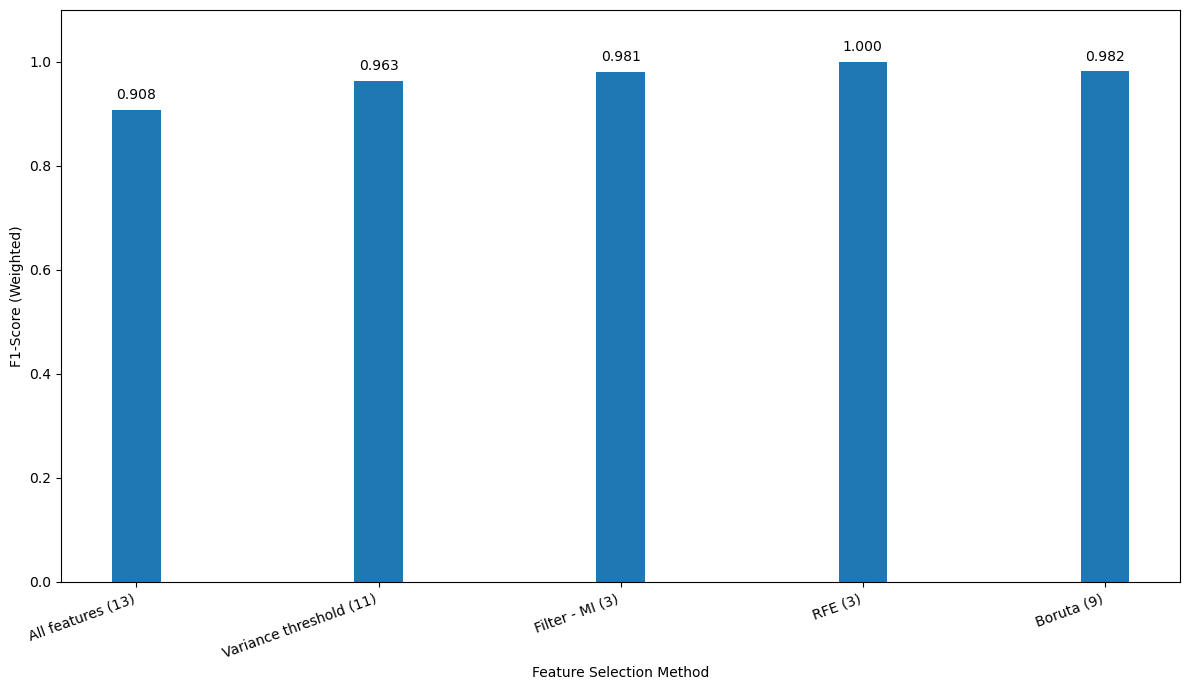

In [53]:
fig, ax = plt.subplots(figsize=(12, 7))

x = ['All features (13)', 'Variance threshold (11)',
     'Filter - MI (3)', 'RFE (3)', 'Boruta (9)']

y = [f1_score_all, f1_score_var, 0.981, 1.0, f1_score_boruta]

bars = ax.bar(x, y, width=0.2)

ax.set_xlabel('Feature Selection Method')
ax.set_ylabel('F1-Score (Weighted)')
ax.set_ylim(0, 1.1)

# Rotate labels so they don't overlap
ax.set_xticks(range(len(x)))
ax.set_xticklabels(x, fontsize=10, rotation=20, ha='right')

# Add values above bars
for bar, value in zip(bars, y):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.015,
        f'{value:.3f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

# Give the plot more room
plt.tight_layout()
plt.show()
